# Lab Notebook: Correlation Analysis Using a World Countries Dataset

This notebook teaches correlation step by step using a real dataset about countries.  
You will learn how to:

1. Understand correlation and correlation coefficient.
2. Distinguish correlation from causation.
3. Create scatter diagrams.
4. Calculate Pearson correlation.
5. Interpret positive, negative, weak, moderate, and strong correlations.
6. Use coefficient of determination \(r^2\).
7. Use Spearman rank correlation when data is rank-based or not normally distributed.
8. Practice with guided tasks and mini-projects.

> Dataset: world countries indicators such as GDP, population, life expectancy, birth rate, unemployment rate, education enrollment, and more.

## 1. Import the Required Libraries

We first import the libraries that we need. Pandas is used for data handling, NumPy for numerical operations, and Matplotlib for visualization.

In [81]:
import pandas as pd      # Import pandas for data handling and analysis (tables, DataFrames)

import numpy as np       # Import numpy for numerical operations (arrays, math functions)

import matplotlib.pyplot as plt   # Import matplotlib for creating basic plots and charts

import seaborn as sns    # Import seaborn for advanced statistical visualizations (built on matplotlib)

%matplotlib inline       
# Display plots directly inside the Jupyter Notebook (no separate window)

## 2. Load the Dataset

The dataset is stored as a CSV file. We load it into a Pandas DataFrame called `df`.

In [84]:

df = pd.read_csv("world_countries_correlation.csv")   # Load the dataset from the CSV file into a DataFrame called df

df.head()                                             # Display the first 5 rows to preview the data and understand its structure

,Country,Density (P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.1,652230.0,323000.0,32.49,93.0,Kabul,8672.0,...,78.4,0.28,38041754.0,48.9,9.3,71.4,11.12,9797273.0,33.939110,67.709953
1,Albania,105,AL,43.1,28748.0,9000.0,11.78,355.0,Tirana,4536.0,...,56.9,1.20,2854191.0,55.7,18.6,36.6,12.33,1747593.0,41.153332,20.168331
2,Algeria,18,DZ,17.4,2381741.0,317000.0,24.28,213.0,Algiers,150006.0,...,28.1,1.72,43053054.0,41.2,37.2,66.1,11.70,31510100.0,28.033886,1.659626
3,Andorra,164,AD,40.0,468.0,NaN,7.20,376.0,Andorra la Vella,469.0,...,36.4,3.33,77142.0,NaN,NaN,NaN,NaN,67873.0,42.506285,1.521801
4,Angola,26,AO,47.5,1246700.0,117000.0,40.73,244.0,Luanda,34693.0,...,33.4,0.21,31825295.0,77.5,9.2,49.1,6.89,21061025.0,-11.202692,17.873887


## 3. Inspect the Dataset

Before calculating correlation, we must understand the structure of the data: number of rows, columns, and data types.

In [87]:
df.info()      # Show the number of rows and columns in the dataset

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    str    
 1   Density (P/Km2)                            195 non-null    int64  
 2   Abbreviation                               188 non-null    str    
 3   Agricultural Land( %)                      188 non-null    float64
 4   Land Area(Km2)                             194 non-null    float64
 5   Armed Forces size                          171 non-null    float64
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    str    
 9   Co2-Emissions                              188 non-null    float64
 10  CPI                                  

## 4. Select Numerical Columns

Correlation is usually calculated between numerical variables. Here we select only numeric columns from the dataset.

In [90]:
numeric_df = df.select_dtypes(include=["int64", "float64"])   # Select only numerical columns (integers and floats) from the dataset

numeric_df.head()                                            # Display the first 5 rows of the numerical data to verify the selection

,Density (P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,60,58.1,652230.0,323000.0,32.49,93.0,8672.0,149.90,2.3,4.47,...,78.4,0.28,38041754.0,48.9,9.3,71.4,11.12,9797273.0,33.939110,67.709953
1,105,43.1,28748.0,9000.0,11.78,355.0,4536.0,119.05,1.4,1.62,...,56.9,1.20,2854191.0,55.7,18.6,36.6,12.33,1747593.0,41.153332,20.168331
2,18,17.4,2381741.0,317000.0,24.28,213.0,150006.0,151.36,2.0,3.02,...,28.1,1.72,43053054.0,41.2,37.2,66.1,11.70,31510100.0,28.033886,1.659626
3,164,40.0,468.0,NaN,7.20,376.0,469.0,NaN,NaN,1.27,...,36.4,3.33,77142.0,NaN,NaN,NaN,NaN,67873.0,42.506285,1.521801
4,26,47.5,1246700.0,117000.0,40.73,244.0,34693.0,261.73,17.1,5.52,...,33.4,0.21,31825295.0,77.5,9.2,49.1,6.89,21061025.0,-11.202692,17.873887


## 5. Check Missing Values

Missing values can affect correlation results. We check how many missing values exist in each numerical column.

In [93]:
missing_values = numeric_df.isnull().sum()                     # Count how many missing (NaN) values exist in each numerical column

missing_values = missing_values.sort_values(ascending=False)   # Sort columns from highest to lowest missing values

missing_values                                                 # Display the result to identify which columns need cleaning

Minimum wage                                 45
Tax revenue (%)                              26
Armed Forces size                            24
Gasoline Price                               20
Population: Labor force participation (%)    19
Unemployment rate                            19
CPI                                          17
CPI Change (%)                               16
Maternal mortality ratio                     14
Total tax rate                               12
Gross tertiary education enrollment (%)      12
Life expectancy                               8
Forested Area (%)                             7
Fertility Rate                                7
Gross primary education enrollment (%)        7
Agricultural Land( %)                         7
Co2-Emissions                                 7
Out of pocket health expenditure              7
Physicians per thousand                       7
Infant mortality                              6
Birth Rate                              

## 6. What Is Correlation?

Correlation measures the **degree and direction of relationship** between two variables.

- A **positive correlation** means both variables tend to move in the same direction.
- A **negative correlation** means variables tend to move in opposite directions.
- A correlation close to **0** means there is little or no linear relationship.

The Pearson correlation coefficient is usually denoted by **r** and ranges from:

 r: from -1 to +1

## 7. Correlation vs. Causation

Correlation does **not** automatically mean causation.

Example: If GDP and CO2 emissions are positively correlated, this does not prove that GDP alone causes CO2 emissions. Other factors such as industrialization, population size, and energy policy may also play a role.

## 8. Scatter Diagram Method

A scatter diagram shows each observation as a point with an **X value** and a **Y value**. It helps us visually identify:

- Direction of the relationship
- Form of the relationship
- Strength of the relationship
- Possible outliers

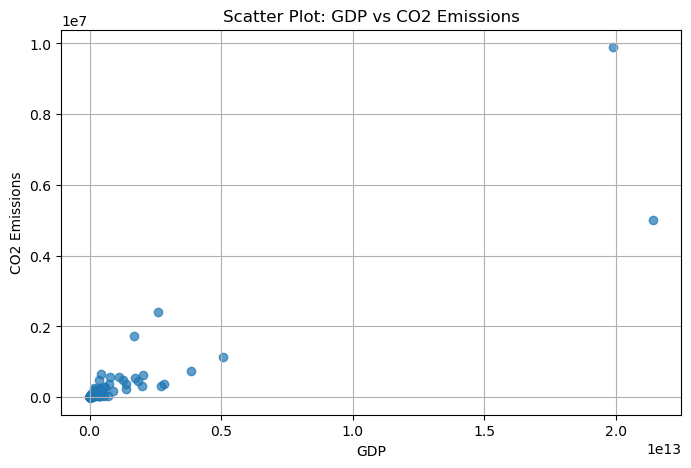

In [101]:
plt.figure(figsize=(8, 5))                                # Create a new figure with a specific size (width=8, height=5)

plt.scatter(df["GDP"], df["Co2-Emissions"], alpha=0.7)    # Plot a scatter plot: GDP on x-axis, CO2 emissions on y-axis (alpha controls transparency)

plt.title("Scatter Plot: GDP vs CO2 Emissions")           # Add a title to describe the relationship between the variables
plt.xlabel("GDP")                                         # Label the x-axis to indicate it represents GDP

plt.ylabel("CO2 Emissions")                               # Label the y-axis to indicate it represents CO2 emissions

plt.grid(True)                                            # Add grid lines to improve readability of the plot

plt.show()                                               # Display the plot inside the notebook

### Interpretation

### 📊 **Simple Interpretation (GDP vs CO₂ Emissions)**

* There is a **positive relationship** → higher GDP → higher CO₂ emissions
* The relationship is **not perfectly linear** (points are scattered)
* A few **outliers (very rich countries)** strongly affect the pattern
* Most countries are **clustered at low GDP and low emissions**
* Overall: **GDP is related to emissions, but not the only factor**


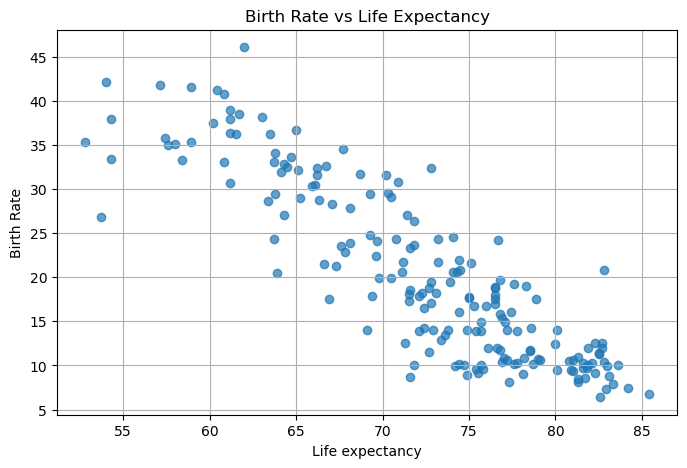

In [108]:
plt.figure(figsize=(8, 5))                     # Create figure

plt.scatter(df["Life expectancy"],                  # X-axis
            df["Birth Rate"], 
            alpha=0.7)                         # Transparency

plt.title("Birth Rate vs Life Expectancy")     # Title

plt.xlabel("Life expectancy")                       # X label
plt.ylabel("Birth Rate")                  # Y label

plt.grid(True)                                 # Grid

plt.show()                                     # Display

## 9. Pearson Correlation Coefficient

Pearson correlation measures the strength and direction of a **linear relationship** between two numerical variables.

Assumptions usually include:

- Variables are continuous.
- Each observation has a pair of values.
- The relationship is approximately linear.
- Extreme outliers should be checked.
- For formal statistical testing, normality and homoscedasticity are often considered.

In [117]:
pearson_gdp_co2 = df["GDP"].corr(df["Co2-Emissions"], method="pearson")   # Compute Pearson correlation between GDP and CO2 emissions

print("Pearson correlation between GDP and CO2 emissions:", 
      round(pearson_gdp_co2, 3))                                          # Print the result rounded to 3 decimal places

Pearson correlation between GDP and CO2 emissions: 0.917


### Interpretation:

Countries with higher GDP tend to produce much higher CO₂ emissions, and the relationship is very strong.

## 10. Build a Simple Interpretation Function

The following function helps students interpret the correlation coefficient automatically.

In [124]:
def analyze_correlation(df, var1, var2):                         # Function takes dataset and two variable names
    
    r = df[var1].corr(df[var2], method="pearson")                # Compute Pearson correlation
    
    if r == 1:
        strength = "Perfect positive correlation"
    
    elif r >= 0.90:
        strength = "Very strong positive correlation"
    
    elif r >= 0.70:
        strength = "Strong positive correlation"
    
    elif r >= 0.50:
        strength = "Moderate positive correlation"
    
    elif r >= 0.30:
        strength = "Weak positive correlation"
    
    elif r > 0:
        strength = "Very weak positive correlation"
    
    elif r == 0:
        strength = "No linear correlation"
    
    elif r > -0.30:
        strength = "Very weak negative correlation"
    
    elif r > -0.50:
        strength = "Weak negative correlation"
    
    elif r > -0.70:
        strength = "Moderate negative correlation"
    
    elif r > -0.90:
        strength = "Strong negative correlation"
    
    elif r > -1:
        strength = "Very strong negative correlation"
    
    else:
        strength = "Perfect negative correlation"
    
    print(f"Correlation between {var1} and {var2}: {round(r, 3)}")   # Print correlation value
    print(f"Interpretation: {strength}")                             # Print interpretation

In [126]:
analyze_correlation(df, "GDP", "Co2-Emissions")        # Economic vs environmental
analyze_correlation(df, "GDP", "Life expectancy")      # Economy vs health
analyze_correlation(df, "Birth Rate", "Life expectancy")  # Demographics
analyze_correlation(df, "Population", "GDP")           # Size vs economy
analyze_correlation(df, "Unemployment rate", "GDP")    # Labor vs economy

Correlation between GDP and Co2-Emissions: 0.917
Interpretation: Very strong positive correlation
Correlation between GDP and Life expectancy: 0.176
Interpretation: Very weak positive correlation
Correlation between Birth Rate and Life expectancy: -0.875
Interpretation: Strong negative correlation
Correlation between Population and GDP: 0.632
Interpretation: Moderate positive correlation
Correlation between Unemployment rate and GDP: 0.031
Interpretation: Very weak positive correlation


## 11. Try Several Correlations

Now we calculate correlations between several meaningful pairs of variables.

In [133]:
pairs = [                                                    # Define variable pairs to analyze
    ("GDP", "Co2-Emissions"),
    ("GDP", "Population"),
    ("Life expectancy", "Birth Rate"),
    ("Life expectancy", "Infant mortality"),
    ("Gross tertiary education enrollment (%)", "Life expectancy"),
    ("Physicians per thousand", "Life expectancy"),
    ("Unemployment rate", "GDP")
]

results = []                                                 # Create empty list to store results

for x_col, y_col in pairs:                                   # Loop through each pair
    
    r = df[x_col].corr(df[y_col], method="pearson")          # Compute Pearson correlation
    
    results.append([x_col,                                   # Store variable X
                    y_col,                                   # Store variable Y
                    round(r, 3)])                            # Store rounded correlation only

correlation_results = pd.DataFrame(                          # Convert results into DataFrame
    results, 
    columns=["Variable X", "Variable Y", "Pearson r"]        # Remove Interpretation column
)

correlation_results                                         # Display results table

,Variable X,Variable Y,Pearson r
0,GDP,Co2-Emissions,0.917
1,GDP,Population,0.632
2,Life expectancy,Birth Rate,-0.875
3,Life expectancy,Infant mortality,-0.925
4,Gross tertiary education enrollment (%),Life expectancy,0.723
5,Physicians per thousand,Life expectancy,0.704
6,Unemployment rate,GDP,0.031


## 12. Correlation Matrix

A correlation matrix shows the correlation between many variables at the same time.

In [136]:
# Select important numerical columns for correlation analysis
selected_cols = [
    "GDP",
    "Population",
    "Co2-Emissions",
    "Life expectancy",
    "Birth Rate",
    "Fertility Rate",
    "Infant mortality",
    "Gross tertiary education enrollment (%)",
    "Physicians per thousand",
    "Unemployment rate",
    "Urban_population"
]

# Calculate the Pearson correlation matrix for the selected columns
corr_matrix = df[selected_cols].corr(method="pearson")

# Display the correlation matrix
corr_matrix.round(2)

,GDP,Population,Co2-Emissions,Life expectancy,Birth Rate,Fertility Rate,Infant mortality,Gross tertiary education enrollment (%),Physicians per thousand,Unemployment rate,Urban_population
GDP,1.00,0.63,0.92,0.18,-0.18,-0.16,-0.15,0.21,0.09,0.03,0.78
Population,0.63,1.00,0.81,0.01,-0.05,-0.06,0.00,0.03,-0.05,-0.04,0.95
Co2-Emissions,0.92,0.81,1.00,0.12,-0.16,-0.14,-0.12,0.16,0.06,0.01,0.93
Life expectancy,0.18,0.01,0.12,1.00,-0.87,-0.85,-0.92,0.72,0.70,-0.04,0.07
Birth Rate,-0.18,-0.05,-0.16,-0.87,1.00,0.98,0.87,-0.73,-0.74,-0.04,-0.11
Fertility Rate,-0.16,-0.06,-0.14,-0.85,0.98,1.00,0.85,-0.68,-0.68,-0.07,-0.10
Infant mortality,-0.15,0.00,-0.12,-0.92,0.87,0.85,1.00,-0.72,-0.69,0.00,-0.06
Gross tertiary education enrollment (%),0.21,0.03,0.16,0.72,-0.73,-0.68,-0.72,1.00,0.72,0.04,0.10
Physicians per thousand,0.09,-0.05,0.06,0.70,-0.74,-0.68,-0.69,0.72,1.00,0.00,0.00
Unemployment rate,0.03,-0.04,0.01,-0.04,-0.04,-0.07,0.00,0.04,0.00,1.00,-0.01


## 13. Visualize the Correlation Matrix

A heatmap makes the correlation matrix easier to understand visually.

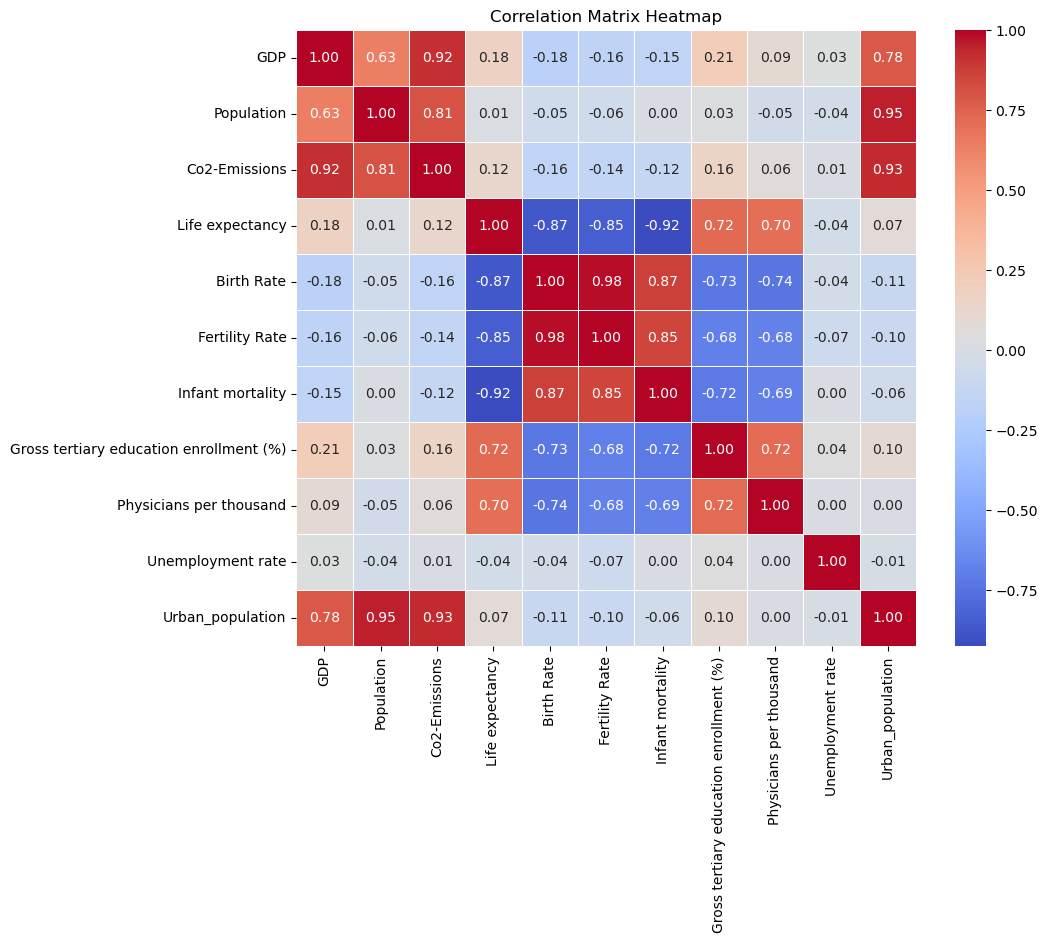

In [71]:
plt.figure(figsize=(10, 8))                             # Create a figure with good size for readability

sns.heatmap(corr_matrix,                                # Plot the correlation matrix
            annot=True,                                 # Display correlation values inside each cell
            fmt=".2f",                                  # Format numbers to 2 decimal places
            cmap="coolwarm",                            # Use color map (blue=positive, red=negative)
            linewidths=0.5)                             # Add lines between cells for clarity

plt.title("Correlation Matrix Heatmap")                 # Add a clear title

plt.show()                                              # Display the heatmap

## 14. Coefficient of Determination \(r^2\)

The coefficient of determination is calculated by squaring the correlation coefficient:

\[
r^2
\]

It tells us the approximate proportion of variation in one variable that is explained by the other variable in a linear relationship.

In [74]:
r_squared_gdp_co2 = pearson_gdp_co2 ** 2              # Square the correlation to get coefficient of determination (r²)

print("r:", round(pearson_gdp_co2, 3))               # Print correlation value (strength & direction)

print("r squared:", round(r_squared_gdp_co2, 3))     # Print r² value (proportion of explained variance)

print("Percentage explained:",                       # Convert r² into percentage
      round(r_squared_gdp_co2 * 100, 1), "%")

r: 0.917
r squared: 0.841
Percentage explained: 84.1 %


### Important Note

If \(r = 0.60\), then \(r^2 = 0.36\). This means about **36%** of the variation is explained, not 60%.

## 15. Spearman Rank Correlation

Spearman correlation is used when:

- The data is ordinal or rank-based.
- The data is numeric but not normally distributed.
- The relationship is monotonic but not necessarily linear.

Spearman correlation uses ranks instead of raw values.

In [76]:
spearman_gdp_co2 = df["GDP"].corr(df["Co2-Emissions"], method="spearman")   # Compute Spearman (rank-based) correlation

print("Pearson correlation:",  round(pearson_gdp_co2, 3))                   # Print Pearson correlation (linear relationship)

print("Spearman correlation:", round(spearman_gdp_co2, 3))                  # Print Spearman correlation (monotonic relationship)

Pearson correlation: 0.917
Spearman correlation: 0.948


## 18. Detect Possible Outliers Visually

Outliers can strongly affect Pearson correlation. A scatter plot is one of the simplest ways to notice them.

In [ ]:
# Create a scatter plot to check for outliers in GDP and Population
plt.figure(figsize=(8, 5))

# Plot GDP against Population
plt.scatter(df["GDP"], df["Population"], alpha=0.7)

# Add chart title
plt.title("Checking Possible Outliers: GDP vs Population")

# Add x-axis label
plt.xlabel("GDP")

# Add y-axis label
plt.ylabel("Population")

# Add grid lines
plt.grid(True)

# Display the chart
plt.show()

## 22. Summary

In this notebook, you learned that:

- Correlation measures relationship, not cause and effect.
- Pearson correlation measures linear relationships between numerical variables.
- Spearman correlation measures rank-based or monotonic relationships.
- Scatter diagrams help us visually understand correlation.
- The coefficient of determination \(r^2\) helps interpret the percentage of explained variation.
- Outliers and skewed data can affect correlation results.